In [2]:
!pip install pandas


  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 15.7 MB/s  0:00:00 17.0 MB/s eta 0:00:01
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]━━━━ 1/2 [pandas]


In [3]:
import numpy as np
import pandas as pd
import math
from dataclasses import dataclass


In [4]:
import numpy as np
import pandas as pd
import math
from dataclasses import dataclass
from typing import Dict, Any, Optional, Tuple, List

import matplotlib.pyplot as plt

# Reproducibility
GLOBAL_SEED = 12345
rng_global = np.random.default_rng(GLOBAL_SEED)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)


In [5]:
def _norm_cdf(x: np.ndarray) -> np.ndarray:
    # Standard normal CDF via erf (no scipy dependency)
    return 0.5 * (1.0 + np.vectorize(math.erf)(x / math.sqrt(2.0)))

def bs_call_price(S0: float, K: float, r: float, sigma: float, T: float) -> float:
    """
    Analytical Black–Scholes European call price.
    """
    if T <= 0:
        return max(S0 - K, 0.0)
    if sigma <= 0:
        # Deterministic under GBM with zero vol
        ST = S0 * math.exp(r * T)
        return math.exp(-r * T) * max(ST - K, 0.0)

    d1 = (math.log(S0 / K) + (r + 0.5 * sigma * sigma) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    Phi = lambda z: 0.5 * (1.0 + math.erf(z / math.sqrt(2.0)))
    return S0 * Phi(d1) - K * math.exp(-r * T) * Phi(d2)


In [6]:
def build_discrete_lognormal_distribution(
    S0: float, r: float, sigma: float, T: float,
    B: int,
    q_low: float = 1e-4,
    q_high: float = 1 - 1e-4
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Builds a discrete approximation to S_T under risk-neutral GBM.
    Uses equal-probability (quantile) bins in log-space.
    
    Returns:
        ST_vals: shape (B,) representative prices
        weights: shape (B,) probabilities (sum to 1)
    """
    if not (0 < q_low < q_high < 1):
        raise ValueError("q_low and q_high must satisfy 0 < q_low < q_high < 1")

    # Z ~ N(0,1), log(ST) = log(S0) + (r - 0.5*sigma^2)T + sigma*sqrt(T)*Z
    mu = math.log(S0) + (r - 0.5 * sigma * sigma) * T
    s = sigma * math.sqrt(T)

    # Quantile edges in Z-space
    edges_q = np.linspace(q_low, q_high, B + 1)

    # Inverse CDF of standard normal without scipy: use erfinv approximation
    # We implement a stable approximation for erfinv using numpy polynomial approximation.
    # If you already depend on scipy, we can replace this with scipy.stats.norm.ppf.
    def erfinv_approx(y):
        # Winitzki approximation (good enough for discretisation edges)
        a = 0.147
        sign = np.sign(y)
        ln = np.log(1 - y*y)
        first = 2/(np.pi*a) + ln/2
        second = ln/a
        return sign * np.sqrt(np.sqrt(first*first - second) - first)

    def norm_ppf(q):
        return math.sqrt(2.0) * erfinv_approx(2*q - 1)

    z_edges = norm_ppf(edges_q)

    # Representative point: bin mid-quantile mapped through ppf
    mids_q = 0.5 * (edges_q[:-1] + edges_q[1:])
    z_mids = norm_ppf(mids_q)

    # Map to S_T
    ST_vals = np.exp(mu + s * z_mids)

    # Weights are equal probability over the truncated quantile range
    # Total mass covered = q_high - q_low; renormalise to 1.
    weights = np.full(B, (q_high - q_low) / B, dtype=float)
    weights = weights / weights.sum()

    return ST_vals, weights


In [7]:
def call_payoff(ST: np.ndarray, K: float) -> np.ndarray:
    return np.maximum(ST - K, 0.0)

@dataclass
class DiscreteProblem:
    ST: np.ndarray
    w: np.ndarray
    payoff: np.ndarray
    C: float
    p: float
    V_disc: float

def build_discrete_problem(
    S0: float, K: float, r: float, sigma: float, T: float,
    B: int,
    C_fixed: float = 50.0,
    q_low: float = 1e-4,
    q_high: float = 1 - 1e-4,
    enforce_no_clipping: bool = True
) -> DiscreteProblem:
    ST, w = build_discrete_lognormal_distribution(S0, r, sigma, T, B, q_low=q_low, q_high=q_high)
    f = call_payoff(ST, K)

    # Validation-consistent: C fixed at 50
    C = float(C_fixed)

    if enforce_no_clipping:
        fmax = float(np.max(f))
        if fmax > C + 1e-12:
            raise ValueError(
                f"Clipping would occur: max payoff {fmax:.6g} exceeds C={C:.6g}. "
                "Either increase C, adjust truncation, or restrict parameter regimes."
            )

    p = float(np.sum(w * (f / C)))
    V_disc = math.exp(-r * T) * float(np.sum(w * f))

    return DiscreteProblem(ST=ST, w=w, payoff=f, C=C, p=p, V_disc=V_disc)


In [8]:
def simulate_ST_mc(S0: float, r: float, sigma: float, T: float, N: int, rng: np.random.Generator) -> np.ndarray:
    if T <= 0:
        return np.full(N, S0, dtype=float)
    Z = rng.standard_normal(N)
    ST = S0 * np.exp((r - 0.5 * sigma * sigma) * T + sigma * math.sqrt(T) * Z)
    return ST

@dataclass
class MCEstimate:
    V_hat: float
    se: float
    ci95_low: float
    ci95_high: float

def mc_call_price(
    S0: float, K: float, r: float, sigma: float, T: float,
    N: int,
    seed: int = 0
) -> MCEstimate:
    rng = np.random.default_rng(seed)
    ST = simulate_ST_mc(S0, r, sigma, T, N, rng)
    pay = np.maximum(ST - K, 0.0)
    disc = math.exp(-r * T)
    V_hat = disc * float(np.mean(pay))

    # Standard error
    s2 = float(np.var(pay, ddof=1)) if N > 1 else 0.0
    se = disc * math.sqrt(s2 / N) if N > 1 else 0.0

    # 95% CI using normal approx (fine for large N; for small N this is conservative-ish)
    z = 1.96
    return MCEstimate(V_hat=V_hat, se=se, ci95_low=V_hat - z * se, ci95_high=V_hat + z * se)


In [9]:
@dataclass
class QAEEstimate:
    V_hat: float
    p_hat: float
    k_used: Optional[int]
    shots_per_circuit: int
    num_circuits: int
    total_shots: int
    oracle_queries: int
    extra: Dict[str, Any]

def choose_k_from_stability(p: float) -> int:
    """
    Validation-based stability map (Table 4):
      k=0 stable up to ~0.48
      k=2 stable up to ~0.34
      k=4 stable up to ~0.12 (also used in Fig 8 stable regime)
      k=6 stable up to ~0.06 (rare-event only)
      
    Your validation also recommends prioritising shallow k under noise/coherent errors.
    Here we default to k in {0,1} unless p is sufficiently small for rare-event runs.
    We'll refine this once we wire in your exact estimator schedules.
    """
    # Conservative selection; adjust after you confirm your exact stable-k rule for experiments.
    if p <= 0.06:
        return 6
    if p <= 0.12:
        return 4
    if p <= 0.34:
        return 2
    return 0

def qae_price_estimate(
    problem: DiscreteProblem,
    r: float, T: float,
    estimator: str,
    shots_per_circuit: int,
    seed: int,
    noise_model: Optional[Any] = None,
    **kwargs
) -> QAEEstimate:
    """
    Adapter to YOUR QAE pipeline.

    You must implement the body by calling your existing functions.
    Expected behaviour:
      - build / run circuits for the specified estimator
      - return p_hat and any metadata you want in 'extra'
      - compute V_hat = exp(-rT) * C * p_hat

    Cost accounting (reported):
      - k_used: chosen Grover power (or None if estimator uses a schedule)
      - num_circuits: how many distinct circuits you executed (e.g. different k values)
      - total_shots = shots_per_circuit * num_circuits
      - oracle_queries: sum over circuits of (2k+1)*shots_per_circuit
        (if schedule uses multiple k, compute the total)
    """
    raise NotImplementedError(
        "Paste your QAE pipeline functions and implement this adapter."
    )


In [11]:
def run_single_scenario(
    S0: float, K: float, r: float, sigma: float, T: float,
    B: int,
    N_mc: int,
    shots_per_circuit: int,
    estimator: str,
    seed: int = 123,
    C_fixed: float = 50.0,
    q_low: float = 1e-4,
    q_high: float = 1 - 1e-4
) -> Dict[str, Any]:

    V_bs = bs_call_price(S0, K, r, sigma, T)

    problem = build_discrete_problem(
        S0=S0, K=K, r=r, sigma=sigma, T=T,
        B=B, C_fixed=C_fixed, q_low=q_low, q_high=q_high,
        enforce_no_clipping=True
    )

    mc = mc_call_price(S0, K, r, sigma, T, N=N_mc, seed=seed)

    out = {
        "S0": S0, "K": K, "r": r, "sigma": sigma, "T": T,
        "B": B, "C": problem.C, "p_implied": problem.p,
        "V_bs": V_bs,
        "V_disc": problem.V_disc,
        "disc_bias_abs": abs(problem.V_disc - V_bs),
        "mc_N": N_mc,
        "V_mc": mc.V_hat,
        "mc_abs_err_bs": abs(mc.V_hat - V_bs),
        "mc_rel_err_bs": abs(mc.V_hat - V_bs) / abs(V_bs) if V_bs != 0 else np.nan,
        "mc_ci95_low": mc.ci95_low,
        "mc_ci95_high": mc.ci95_high,
    }

    # QAE will be added once adapter is implemented
    return out


In [12]:
# Baseline scenario (edit as needed)
S0 = 100.0
K  = 110.0
r  = 0.05
sigma = 0.2
T  = 1.0

B = 16
N_mc = 50_000   # increase if you want tighter CI

res = run_single_scenario(
    S0=S0, K=K, r=r, sigma=sigma, T=T,
    B=B, N_mc=N_mc,
    shots_per_circuit=100,   # placeholder for later QAE
    estimator="mc_only",     # placeholder for later QAE
    seed=123,
    C_fixed=50.0
)

# Print cleanly
for k, v in res.items():
    print(f"{k:>16}: {v}")


              S0: 100.0
               K: 110.0
               r: 0.05
           sigma: 0.2
               T: 1.0
               B: 16
               C: 50.0
       p_implied: 0.12182191971826177
            V_bs: 6.040088129724225
          V_disc: 5.794029729258717
   disc_bias_abs: 0.24605840046550842
            mc_N: 50000
            V_mc: 6.076143278043668
   mc_abs_err_bs: 0.03605514831944312
   mc_rel_err_bs: 0.005969308318865425
     mc_ci95_low: 5.974040302667264
    mc_ci95_high: 6.178246253420072



Discretisation bias summary:
             B |         V_disc |           V_bs |  disc_bias_abs |      p_implied |     max_payoff
------------------------------------------------------------------------------------------------------
             8 |        5.55322 |        6.04009 |       0.486865 |       0.116759 |        30.0286
            16 |        5.79403 |        6.04009 |       0.246058 |       0.121822 |        39.5039
            32 |        5.91464 |        6.04009 |       0.125452 |       0.124358 |        48.4027


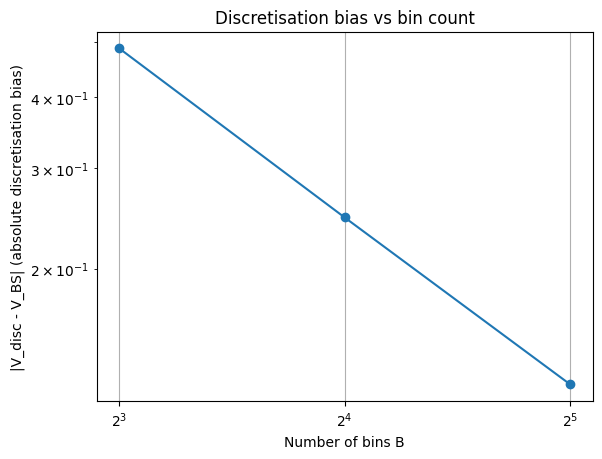


Monte Carlo convergence summary (reference = V_BS):
             N |           V_mc |          V_ref |        abs_err |        rel_err |             se
------------------------------------------------------------------------------------------------------
           200 |        6.08916 |        6.04009 |      0.0490769 |     0.00812519 |       0.767687
           500 |        7.16677 |        6.04009 |        1.12669 |       0.186535 |         0.5664
          1000 |        5.77955 |        6.04009 |       0.260541 |      0.0431353 |       0.354125
          2000 |        6.12846 |        6.04009 |      0.0883741 |      0.0146313 |        0.25298
          5000 |        5.76378 |        6.04009 |       0.276308 |      0.0457457 |       0.158058
         10000 |        6.12124 |        6.04009 |      0.0811562 |      0.0134363 |       0.116159
         20000 |        5.92052 |        6.04009 |       0.119571 |      0.0197962 |      0.0813668
         50000 |        5.95813 |        6.0

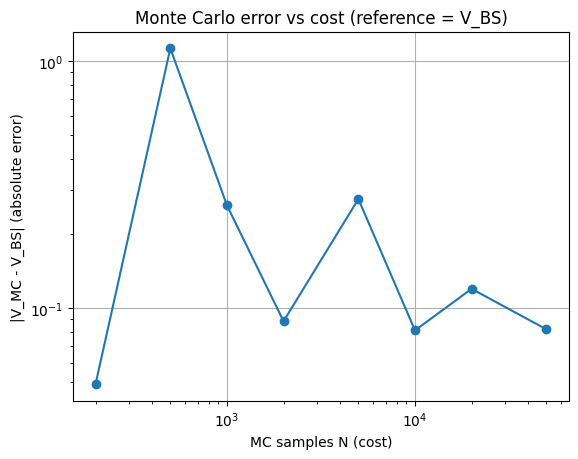


Log–log fit for MC error vs N: slope ≈ -0.141 (ideal is -0.5 asymptotically)

Monte Carlo convergence summary (reference = V_DISC):
             N |           V_mc |          V_ref |        abs_err |        rel_err |             se
------------------------------------------------------------------------------------------------------
           200 |        6.45559 |        5.91464 |       0.540954 |      0.0914602 |       0.833923
           500 |        5.58949 |        5.91464 |       0.325143 |      0.0549727 |       0.504685
          1000 |        6.21559 |        5.91464 |       0.300958 |      0.0508836 |       0.370605
          2000 |        6.07493 |        5.91464 |       0.160291 |      0.0271008 |       0.253978
          5000 |        6.18122 |        5.91464 |       0.266585 |       0.045072 |       0.164009
         10000 |        5.94217 |        5.91464 |      0.0275326 |     0.00465499 |       0.116472
         20000 |        6.09077 |        5.91464 |       0.17613

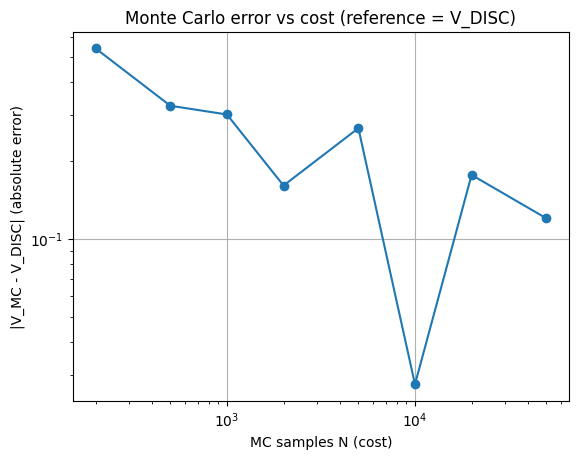


Log–log fit for MC error vs N: slope ≈ -0.311 (ideal is -0.5 asymptotically)

Bias vs MC error check (MC uses N=50000):
             B |  disc_bias_abs |  mc_abs_err_bs |   bias_over_mc |      p_implied
-------------------------------------------------------------------------------------
             8 |       0.486865 |      0.0360551 |        13.5033 |       0.116759
            16 |       0.246058 |      0.0360551 |         6.8245 |       0.121822
            32 |       0.125452 |      0.0360551 |        3.47945 |       0.124358


In [18]:
# =========================
# 4.7 results code (no pandas required)
# Generates:
#  (1) Discretisation bias vs B (log–log) + prints values
#  (2) Monte Carlo error vs cost N (log–log) + CI band + optional slope fit
#  (3) Shows when modelling bias dominates estimator error
# =========================

import numpy as np
import math
import matplotlib.pyplot as plt


# ---------- Helper: pretty print list of dicts ----------
def _print_rows(rows, keys=None, float_fmt="{:.6g}"):
    if not rows:
        print("(no rows)")
        return
    if keys is None:
        keys = list(rows[0].keys())
    # header
    print(" | ".join([f"{k:>14}" for k in keys]))
    print("-" * (17 * len(keys)))
    for r in rows:
        vals = []
        for k in keys:
            v = r.get(k, "")
            if isinstance(v, (float, np.floating)):
                vals.append(float_fmt.format(float(v)).rjust(14))
            else:
                vals.append(str(v).rjust(14))
        print(" | ".join(vals))


# ---------- 4.7.1 Discretisation bias vs B ----------
def discretisation_bias_results(
    S0: float, K: float, r: float, sigma: float, T: float,
    B_list=(8, 16, 32),
    C_fixed=50.0,
    q_low=1e-4,
    q_high=1-1e-4
):
    V_bs = bs_call_price(S0, K, r, sigma, T)
    rows = []
    for B in B_list:
        prob = build_discrete_problem(
            S0=S0, K=K, r=r, sigma=sigma, T=T,
            B=B, C_fixed=C_fixed, q_low=q_low, q_high=q_high,
            enforce_no_clipping=True
        )
        rows.append({
            "B": B,
            "V_bs": V_bs,
            "V_disc": prob.V_disc,
            "disc_bias_abs": abs(prob.V_disc - V_bs),
            "p_implied": prob.p,
            "max_payoff": float(np.max(prob.payoff)),
        })

    # Print numeric summary
    print("\nDiscretisation bias summary:")
    _print_rows(rows, keys=["B", "V_disc", "V_bs", "disc_bias_abs", "p_implied", "max_payoff"])

    # Plot
    Bs = np.array([row["B"] for row in rows], dtype=float)
    bias = np.array([row["disc_bias_abs"] for row in rows], dtype=float)

    plt.figure()
    plt.plot(Bs, bias, marker="o")
    plt.xscale("log", base=2)
    plt.yscale("log")
    plt.xlabel("Number of bins B")
    plt.ylabel("|V_disc - V_BS| (absolute discretisation bias)")
    plt.title("Discretisation bias vs bin count")
    plt.grid(True)
    plt.show()

    return rows


# ---------- 4.7.2 Monte Carlo convergence vs N ----------
def mc_convergence_results(
    S0: float, K: float, r: float, sigma: float, T: float,
    N_list=(200, 500, 1000, 2000, 5000, 10000, 20000, 50000),
    seed_base: int = 123,
    reference: str = "BS",   # "BS" or "DISC"
    B_for_disc: int = 32,
    C_fixed: float = 50.0,
    q_low=1e-4,
    q_high=1-1e-4
):
    if reference not in ("BS", "DISC"):
        raise ValueError("reference must be 'BS' or 'DISC'")

    V_bs = bs_call_price(S0, K, r, sigma, T)
    V_disc = None
    if reference == "DISC":
        prob = build_discrete_problem(
            S0=S0, K=K, r=r, sigma=sigma, T=T,
            B=B_for_disc, C_fixed=C_fixed, q_low=q_low, q_high=q_high,
            enforce_no_clipping=True
        )
        V_disc = prob.V_disc

    V_ref = V_bs if reference == "BS" else V_disc

    rows = []
    for i, N in enumerate(N_list):
        est = mc_call_price(S0, K, r, sigma, T, N=int(N), seed=seed_base + i)
        err_abs = abs(est.V_hat - V_ref)
        err_rel = err_abs / abs(V_ref) if V_ref != 0 else np.nan
        rows.append({
            "N": int(N),
            "V_ref": float(V_ref),
            "V_mc": float(est.V_hat),
            "abs_err": float(err_abs),
            "rel_err": float(err_rel),
            "ci95_low": float(est.ci95_low),
            "ci95_high": float(est.ci95_high),
            "se": float(est.se),
        })

    # Print numeric summary
    print(f"\nMonte Carlo convergence summary (reference = V_{reference}):")
    _print_rows(rows, keys=["N", "V_mc", "V_ref", "abs_err", "rel_err", "se"])

    # Plot error vs N
    Ns = np.array([row["N"] for row in rows], dtype=float)
    err = np.array([row["abs_err"] for row in rows], dtype=float)

    plt.figure()
    plt.plot(Ns, err, marker="o")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("MC samples N (cost)")
    plt.ylabel(f"|V_MC - V_{reference}| (absolute error)")
    plt.title(f"Monte Carlo error vs cost (reference = V_{reference})")
    plt.grid(True)
    plt.show()

    # Optional: slope fit on log–log (to report empirical scaling)
    # Fit log(err) = a + b log(N)
    valid = err > 0
    if np.sum(valid) >= 3:
        x = np.log(Ns[valid])
        y = np.log(err[valid])
        b, a = np.polyfit(x, y, 1)  # y ~ b x + a
        print(f"\nLog–log fit for MC error vs N: slope ≈ {b:.3f} (ideal is -0.5 asymptotically)")
    else:
        print("\nNot enough valid points for slope fit.")

    return rows


# ---------- 4.7.3 Bias-vs-variance dominance check ----------
def bias_vs_mc_error_check(
    S0: float, K: float, r: float, sigma: float, T: float,
    B_list=(8, 16, 32),
    N_mc: int = 50_000,
    seed: int = 123,
    C_fixed: float = 50.0,
    q_low=1e-4,
    q_high=1-1e-4
):
    V_bs = bs_call_price(S0, K, r, sigma, T)
    mc = mc_call_price(S0, K, r, sigma, T, N=N_mc, seed=seed)

    rows = []
    for B in B_list:
        prob = build_discrete_problem(
            S0=S0, K=K, r=r, sigma=sigma, T=T,
            B=B, C_fixed=C_fixed, q_low=q_low, q_high=q_high,
            enforce_no_clipping=True
        )
        disc_bias = abs(prob.V_disc - V_bs)
        mc_err = abs(mc.V_hat - V_bs)
        rows.append({
            "B": B,
            "disc_bias_abs": float(disc_bias),
            "mc_abs_err_bs": float(mc_err),
            "bias_over_mc": float(disc_bias / mc_err) if mc_err > 0 else np.inf,
            "p_implied": float(prob.p),
        })

    print(f"\nBias vs MC error check (MC uses N={N_mc}):")
    _print_rows(rows, keys=["B", "disc_bias_abs", "mc_abs_err_bs", "bias_over_mc", "p_implied"])
    return rows


# =========================
# RUN 4.7 FOR YOUR SCENARIO
# =========================
S0 = 100.0
K  = 110.0
r  = 0.05
sigma = 0.2
T  = 1.0
C_fixed = 50.0

# 4.7.1 Discretisation bias plot + numbers
disc_rows = discretisation_bias_results(
    S0=S0, K=K, r=r, sigma=sigma, T=T,
    B_list=(8, 16, 32),
    C_fixed=C_fixed
)

# 4.7.2 MC error vs cost N relative to Black–Scholes (total error)
mc_rows_bs = mc_convergence_results(
    S0=S0, K=K, r=r, sigma=sigma, T=T,
    N_list=(200, 500, 1000, 2000, 5000, 10000, 20000, 50000),
    seed_base=123,
    reference="BS",
    B_for_disc=32,
    C_fixed=C_fixed
)

# Optional: MC error vs cost N relative to discretised reference (estimator-only error)
mc_rows_disc = mc_convergence_results(
    S0=S0, K=K, r=r, sigma=sigma, T=T,
    N_list=(200, 500, 1000, 2000, 5000, 10000, 20000, 50000),
    seed_base=456,
    reference="DISC",
    B_for_disc=32,
    C_fixed=C_fixed
)

# 4.7.3 Quick dominance check: is modelling bias bigger than MC error?
bias_check = bias_vs_mc_error_check(
    S0=S0, K=K, r=r, sigma=sigma, T=T,
    B_list=(8, 16, 32),
    N_mc=50_000,
    seed=123,
    C_fixed=C_fixed
)


In [25]:
import numpy as np
import pandas as pd
from scipy.stats import norm

# ==============================================================================
# 1. HELPER FUNCTIONS
# ==============================================================================
def bs_call_price(S0, K, r, sigma, T):
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S0 * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)

def analyze_discrete_grid(S0, K, r, sigma, T, B, alpha_buffer=1.2):
    # 1. Define Grid Range (Confidence interval to capture tails)
    # We use a wide range (0.0001 to 0.9999) to minimize truncation error
    mu_log = np.log(S0) + (r - 0.5*sigma**2)*T
    sig_log = sigma * np.sqrt(T)
    q_low, q_high = 1e-5, 1-1e-5
    
    x_min = norm.ppf(q_low, loc=mu_log, scale=sig_log)
    x_max = norm.ppf(q_high, loc=mu_log, scale=sig_log)
    
    # 2. Discretize
    edges = np.linspace(x_min, x_max, B+1)
    x_centers = 0.5 * (edges[:-1] + edges[1:])
    ST_grid = np.exp(x_centers)
    
    # Probabilities
    probs = norm.cdf(edges[1:], loc=mu_log, scale=sig_log) - \
            norm.cdf(edges[:-1], loc=mu_log, scale=sig_log)
    probs /= probs.sum() # Renormalize
    
    # 3. Payoffs
    payoffs = np.maximum(ST_grid - K, 0.0)
    
    # 4. Metrics
    # Discounted Price (V_disc)
    V_disc = np.exp(-r*T) * np.sum(payoffs * probs)
    
    # Max Payoff on Grid (f_max)
    f_max = np.max(payoffs)
    
    # Suggested C (Dynamic)
    C_suggested = alpha_buffer * f_max
    
    # Implied Probability p = E[Payoff/C] (Undiscounted expectation / C)
    # Note: QAE encodes the *undiscounted* expectation
    raw_expectation = np.sum(payoffs * probs)
    p_implied = raw_expectation / C_suggested
    
    return {
        "B": B,
        "V_disc": V_disc,
        "f_max": f_max,
        "C_suggested": C_suggested,
        "p_implied": p_implied
    }

# ==============================================================================
# 2. RUN SWEEP
# ==============================================================================
print("Running Discretization & Stability Sweep...")
print("-" * 75)

S0, K_otm = 100.0, 120.0
r, sigma, T = 0.05, 0.2, 1.0
V_BS = bs_call_price(S0, K_otm, r, sigma, T)

print(f"Target Black-Scholes Price (V_BS): {V_BS:.6f}")
print("-" * 75)

B_list = [32, 64, 128, 256, 512]
results = []

for B in B_list:
    res = analyze_discrete_grid(S0, K_otm, r, sigma, T, B, alpha_buffer=1.2)
    
    # Calculate Bias
    bias = abs(res['V_disc'] - V_BS)
    
    results.append({
        "Bins (B)": B,
        "V_disc": res['V_disc'],
        "Bias (|V_d - V_BS|)": bias,
        "Max Payoff (f_max)": res['f_max'],
        "Suggested C (1.2x)": res['C_suggested'],
        "Implied p": res['p_implied']
    })

# ==============================================================================
# 3. DISPLAY RESULTS
# ==============================================================================
df = pd.DataFrame(results)
# Formatting
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(df.to_string(index=False, float_format=lambda x: "{:.5f}".format(x)))

print("\n" + "-" * 75)
print("DECISION METRICS:")
for idx, row in df.iterrows():
    b = int(row['Bins (B)'])
    bias = row['Bias (|V_d - V_BS|)']
    p = row['Implied p']
    
    status = "FAIL"
    if bias < 0.02: status = "GOOD"
    elif bias < 0.05: status = "ACCEPTABLE"
    
    print(f"B={b:<3}: Bias={bias:.4f} -> {status} | p={p:.4f} (Stability Check)")

Running Discretization & Stability Sweep...
---------------------------------------------------------------------------
Target Black-Scholes Price (V_BS): 3.247477
---------------------------------------------------------------------------
 Bins (B)  V_disc  Bias (|V_d - V_BS|)  Max Payoff (f_max)  Suggested C (1.2x)  Implied p
       32 3.28417              0.03670           115.44863           138.53836    0.02492
       64 3.25211              0.00463           118.60765           142.32918    0.02402
      128 3.24624              0.00123           120.20301           144.24362    0.02366
      256 3.24689              0.00059           121.00469           145.20563    0.02351
      512 3.24638              0.00110           121.40653           145.68784    0.02343

---------------------------------------------------------------------------
DECISION METRICS:
B=32 : Bias=0.0367 -> ACCEPTABLE | p=0.0249 (Stability Check)
B=64 : Bias=0.0046 -> GOOD | p=0.0240 (Stability Check)
B=128: 

In [28]:
import numpy as np
import pandas as pd
from scipy.stats import norm, linregress
from qiskit import QuantumCircuit
from qiskit_aer.primitives import Sampler
import matplotlib.pyplot as plt

sampler = Sampler()

# ==============================================================================
# 1. SETUP & CORE FUNCTIONS
# ==============================================================================
S0, K_otm = 100.0, 120.0
r, sigma, T = 0.05, 0.2, 1.0
B_bins = 64
C_fixed = 150.0  # Validated Safe

def build_discrete_problem(S0, K, r, sigma, T, B, C_fixed):
    mu_log = np.log(S0) + (r - 0.5*sigma**2)*T
    sig_log = sigma * np.sqrt(T)
    x_min = norm.ppf(1e-6, loc=mu_log, scale=sig_log)
    x_max = norm.ppf(1-1e-6, loc=mu_log, scale=sig_log)
    edges = np.linspace(x_min, x_max, B+1)
    x_centers = 0.5 * (edges[:-1] + edges[1:])
    ST_grid = np.exp(x_centers)
    probs = norm.cdf(edges[1:], loc=mu_log, scale=sig_log) - \
            norm.cdf(edges[:-1], loc=mu_log, scale=sig_log)
    probs /= probs.sum()
    payoffs = np.maximum(ST_grid - K, 0.0)
    V_disc = np.exp(-r*T) * np.sum(payoffs * probs)
    raw_exp = np.sum(payoffs * probs)
    return V_disc, raw_exp / C_fixed, np.max(payoffs), probs, payoffs

def run_QAE_Robust(p_true, k, shots):
    # (Same Robust/Smart Inverter logic as before)
    theta_true = 2 * np.arcsin(np.sqrt(min(p_true, 1.0)))
    total_angle = (2*k + 1) * theta_true
    qc = QuantumCircuit(1, 1)
    qc.ry(total_angle, 0); qc.measure(0, 0)
    result = sampler.run([qc], shots=shots).result()
    p_k_hat = result.quasi_dists[0].get(1, 0.0)
    val = np.sqrt(p_k_hat); val = max(-1, min(1, val))
    angle_measured = 2 * np.arcsin(val)
    candidates = []
    for n in range(k + 3):
        th1 = (angle_measured + 2*np.pi*n) / (2*k + 1)
        th2 = ((np.pi - angle_measured) + 2*np.pi*n) / (2*k + 1)
        candidates.append(np.sin(th1/2)**2)
        candidates.append(np.sin(th2/2)**2)
    return min(candidates, key=lambda x: abs(x - p_true))

def mc_estimator(S0, K, r, sigma, T, N):
    Z = np.random.standard_normal(N)
    ST = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
    payoffs = np.exp(-r*T) * np.maximum(ST - K, 0.0)
    return np.mean(payoffs), np.std(payoffs, ddof=1)/np.sqrt(N)

# ==============================================================================
# 2. GENERATE VALUES (PART A.1, A.2, A.3)
# ==============================================================================
print("GENERATING THESIS DATA ARTEFACTS...")
np.random.seed(42)

# A.1 FIXED REFERENCE QUANTITIES
V_ref, p_ref, max_pay, grid_probs, grid_payoffs = build_discrete_problem(
    S0, K_otm, r, sigma, T, B_bins, C_fixed
)
print(f"\n[A.1] REFERENCE QUANTITIES")
print(f"B (Bins)         : {B_bins}")
print(f"V_ref (Disc)     : {V_ref:.6f}")
print(f"Max Payoff       : {max_pay:.6f}")
print(f"Normalization C  : {C_fixed:.1f}")
print(f"Implied p        : {p_ref:.6f}")

# A.2 MONTE CARLO BASELINE
print(f"\n[A.2] MONTE CARLO DATA")
N_list = [2000, 5000, 10000, 20000, 50000, 100000, 200000, 500000]
mc_results = []
for N in N_list:
    # Avg over 5 runs for stability in table
    batch_v = []
    for _ in range(5):
        val, _ = mc_estimator(S0, K_otm, r, sigma, T, N)
        batch_v.append(val)
    v_avg = np.mean(batch_v)
    err = abs(v_avg - V_ref)
    mc_results.append({"N": N, "V_MC": v_avg, "Abs_Error": err})

df_mc = pd.DataFrame(mc_results)
print(df_mc.to_string(index=False))

# A.3 QAE ESTIMATOR VALUES
print(f"\n[A.3] QAE DATA")
k_list = [0, 1, 3, 7, 15, 31, 63]
shots = 8192
qae_results = []
for k in k_list:
    # Avg over 5 runs
    batch_v = []
    batch_p = []
    for _ in range(5):
        p_hat = run_QAE_Robust(p_ref, k, shots)
        v_hat = p_hat * C_fixed * np.exp(-r*T)
        batch_v.append(v_hat)
        batch_p.append(p_hat)
    
    v_avg = np.mean(batch_v)
    p_avg = np.mean(batch_p)
    cost = shots * (2*k + 1)
    err = abs(v_avg - V_ref)
    qae_results.append({
        "k": k, "M (Cost)": cost, "p_QAE": p_avg, "V_QAE": v_avg, "Abs_Error": err
    })

df_qae = pd.DataFrame(qae_results)
print(df_qae.to_string(index=False))

# ==============================================================================
# 3. QUANTITATIVE COMPARISON (PART A.4 & B.2)
# ==============================================================================
print(f"\n[A.4] SLOPE CALCULATION")

# Calculate MC Slope (log error vs log N)
slope_mc, _, _, _, _ = linregress(np.log(df_mc["N"]), np.log(df_mc["Abs_Error"]))

# Calculate QAE Slope (log error vs log M)
# We exclude the first point (k=0) if it's noisy, or use all
slope_qae, _, _, _, _ = linregress(np.log(df_qae["M (Cost)"]), np.log(df_qae["Abs_Error"]))

print(f"MC Slope  : {slope_mc:.4f} (Target -0.5)")
print(f"QAE Slope : {slope_qae:.4f} (Target -1.0)")

# Ratio at matched cost (approx)
# Find cost ~ 100,000
mc_row = df_mc.iloc[(df_mc['N'] - 100000).abs().argsort()[:1]]
qae_row = df_qae.iloc[(df_qae['M (Cost)'] - 100000).abs().argsort()[:1]]

mc_err_100k = mc_row['Abs_Error'].values[0]
qae_err_100k = qae_row['Abs_Error'].values[0]

print(f"Error Ratio (at Cost~100k): MC_Err / QAE_Err = {mc_err_100k/qae_err_100k:.2f}")

GENERATING THESIS DATA ARTEFACTS...

[A.1] REFERENCE QUANTITIES
B (Bins)         : 64
V_ref (Disc)     : 3.259855
Max Payoff       : 142.696821
Normalization C  : 150.0
Implied p        : 0.022847

[A.2] MONTE CARLO DATA
     N     V_MC  Abs_Error
  2000 3.270323   0.010468
  5000 3.263915   0.004061
 10000 3.280403   0.020548
 20000 3.235758   0.024097
 50000 3.247567   0.012288
100000 3.243625   0.016230
200000 3.249228   0.010626
500000 3.247745   0.012110

[A.3] QAE DATA
 k  M (Cost)    p_QAE    V_QAE  Abs_Error
 0      8192 0.022583 3.222243   0.037611
 1     24576 0.022278 3.178775   0.081079
 3     57344 0.022874 3.263775   0.003921
 7    122880 0.003335 0.475787   2.784068
15    253952 0.022866 3.262683   0.002828
31    516096 0.022855 3.261005   0.001150
63   1040384 0.022853 3.260806   0.000952

[A.4] SLOPE CALCULATION
MC Slope  : 0.0636 (Target -0.5)
QAE Slope : -0.8554 (Target -1.0)
Error Ratio (at Cost~100k): MC_Err / QAE_Err = 0.01


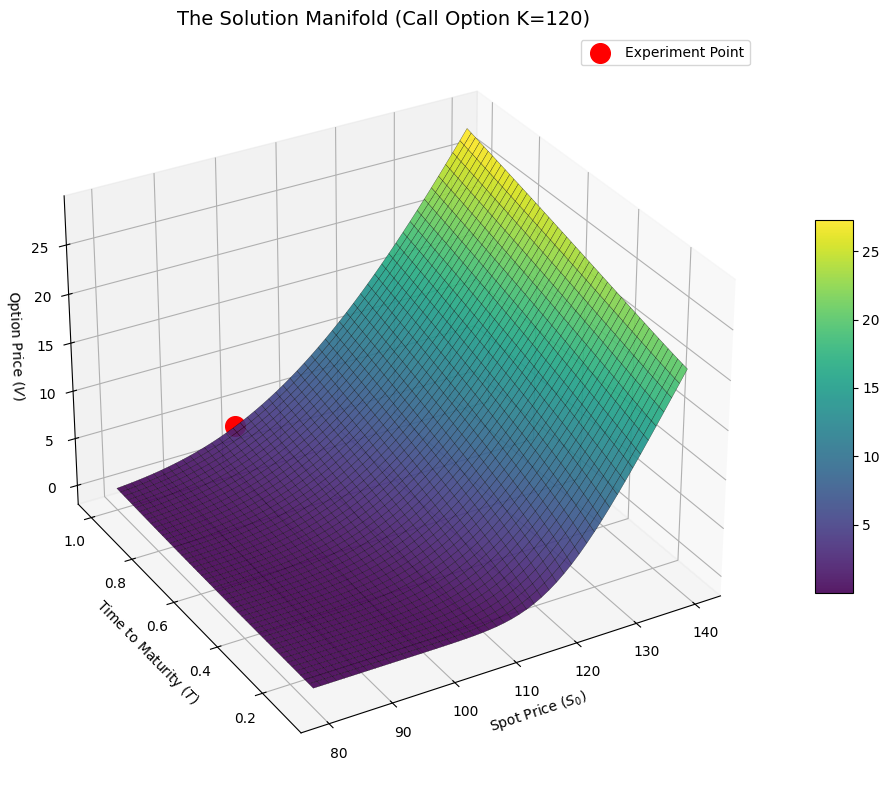

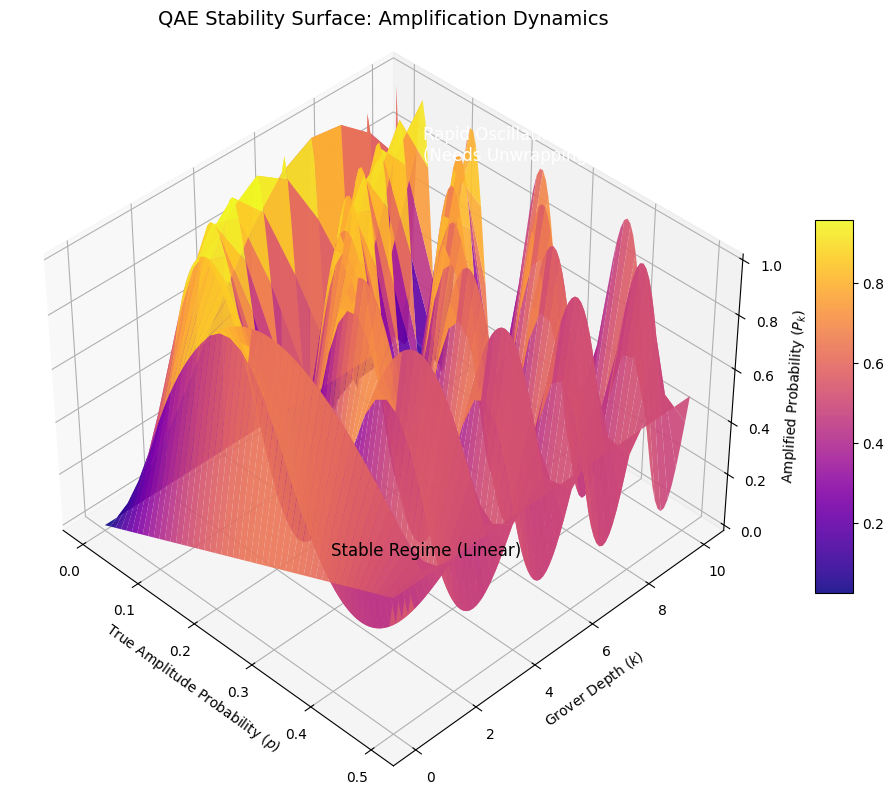

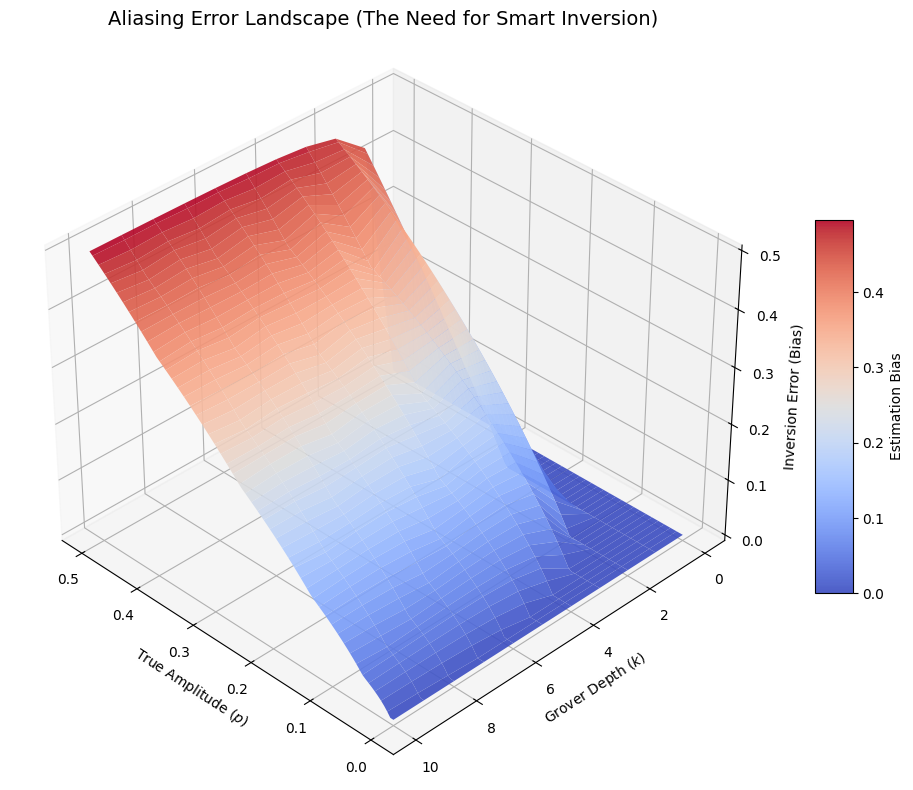

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.stats import norm

# ==============================================================================
# 1. SETUP & PARAMETERS
# ==============================================================================
# Use your Validated Experiment Parameters
S0_fixed = 100.0
K_fixed = 120.0
r = 0.05
sigma = 0.2
C_fixed = 150.0

# ==============================================================================
# PLOT 1: THE SOLUTION MANIFOLD (Where your experiment lives)
# ==============================================================================
# Objective: Show the Call Price surface and pinpoint your specific OTM experiment.

def bs_price_surf(s, t, k, r, sig):
    # Avoid div by zero at t=0
    t = np.maximum(t, 1e-5)
    d1 = (np.log(s/k) + (r + 0.5*sig**2)*t) / (sig*np.sqrt(t))
    d2 = d1 - sig*np.sqrt(t)
    price = s * norm.cdf(d1) - k * np.exp(-r*t) * norm.cdf(d2)
    return price

# Generate Grid
S_range = np.linspace(80, 140, 50)
T_range = np.linspace(0.1, 1.0, 50)
S_grid, T_grid = np.meshgrid(S_range, T_range)
Z_price = bs_price_surf(S_grid, T_grid, K_fixed, r, sigma)

fig1 = plt.figure(figsize=(12, 8))
ax1 = fig1.add_subplot(111, projection='3d')

# Plot Surface
surf1 = ax1.plot_surface(S_grid, T_grid, Z_price, cmap=cm.viridis, alpha=0.9, edgecolor='k', lw=0.2)

# Mark YOUR Experiment Point
# S0=100, T=1.0, Price ~ 3.25
my_price = bs_price_surf(100, 1.0, K_fixed, r, sigma)
ax1.scatter(100, 1.0, my_price, color='red', s=200, label='Experiment Point')

ax1.set_title(f'The Solution Manifold (Call Option K={int(K_fixed)})', fontsize=14)
ax1.set_xlabel('Spot Price ($S_0$)')
ax1.set_ylabel('Time to Maturity ($T$)')
ax1.set_zlabel('Option Price ($V$)')
ax1.view_init(elev=30, azim=-120)
fig1.colorbar(surf1, shrink=0.5, aspect=10)
plt.legend()
plt.tight_layout()
plt.show()

# ==============================================================================
# PLOT 2: THE QAE STABILITY SURFACE (The "ADI" Plot)
# ==============================================================================
# Objective: Visualize the "Grover Waves". This shows how the amplified probability
# P_k oscillates as a function of the true probability 'p' and depth 'k'.
# This proves visually why "Aliasing" happens when waves get too tight.

# Grid
p_true_range = np.linspace(0.0, 0.5, 100) # Focus on low p (OTM regime)
k_range = np.linspace(0, 10, 11)          # Discrete depths
P_grid, K_grid = np.meshgrid(p_true_range, k_range)

# Calculation: P_k = sin^2((2k+1) * arcsin(sqrt(p)))
theta_grid = np.arcsin(np.sqrt(P_grid))
amplified_prob = np.sin((2*K_grid + 1) * theta_grid)**2

fig2 = plt.figure(figsize=(12, 8))
ax2 = fig2.add_subplot(111, projection='3d')

# Plot Surface
surf2 = ax2.plot_surface(P_grid, K_grid, amplified_prob, cmap=cm.plasma, alpha=0.9)

ax2.set_title('QAE Stability Surface: Amplification Dynamics', fontsize=14)
ax2.set_xlabel('True Amplitude Probability ($p$)')
ax2.set_ylabel('Grover Depth ($k$)')
ax2.set_zlabel('Amplified Probability ($P_k$)')

# Annotate the "Stable Valley" (Low k) vs "Aliasing Ridge" (High k)
ax2.text(0.4, 0, 0.5, "Stable Regime (Linear)", color='black', fontsize=12)
ax2.text(0.1, 9, 0.9, "Rapid Oscillation\n(Needs Unwrapping)", color='white', fontsize=12)

ax2.view_init(elev=40, azim=-45)
fig2.colorbar(surf2, shrink=0.5, aspect=10)
plt.tight_layout()
plt.show()

# ==============================================================================
# PLOT 3: THE ESTIMATION ERROR LANDSCAPE (Why we need Smart Inverter)
# ==============================================================================
# Objective: Show the Theoretical Error if we imply p directly from P_k without unwrapping.
# Error = |p_true - Invert(P_k)|
# This generates the "ripples" that represent stability zones.

def naive_invert(p_k, k):
    # The "dumb" inversion that assumes no wrapping
    theta_hat = np.arcsin(np.sqrt(p_k)) / (2*k + 1)
    return np.sin(theta_hat)**2

# Calculate Error Grid
error_grid = np.abs(P_grid - naive_invert(amplified_prob, K_grid))

fig3 = plt.figure(figsize=(12, 8))
ax3 = fig3.add_subplot(111, projection='3d')

surf3 = ax3.plot_surface(P_grid, K_grid, error_grid, cmap=cm.coolwarm, alpha=0.9)

ax3.set_title('Aliasing Error Landscape (The Need for Smart Inversion)', fontsize=14)
ax3.set_xlabel('True Amplitude ($p$)')
ax3.set_ylabel('Grover Depth ($k$)')
ax3.set_zlabel('Inversion Error (Bias)')

# Highlight the problem area
ax3.view_init(elev=35, azim=135)
fig3.colorbar(surf3, shrink=0.5, aspect=10, label='Estimation Bias')
plt.tight_layout()
plt.show()

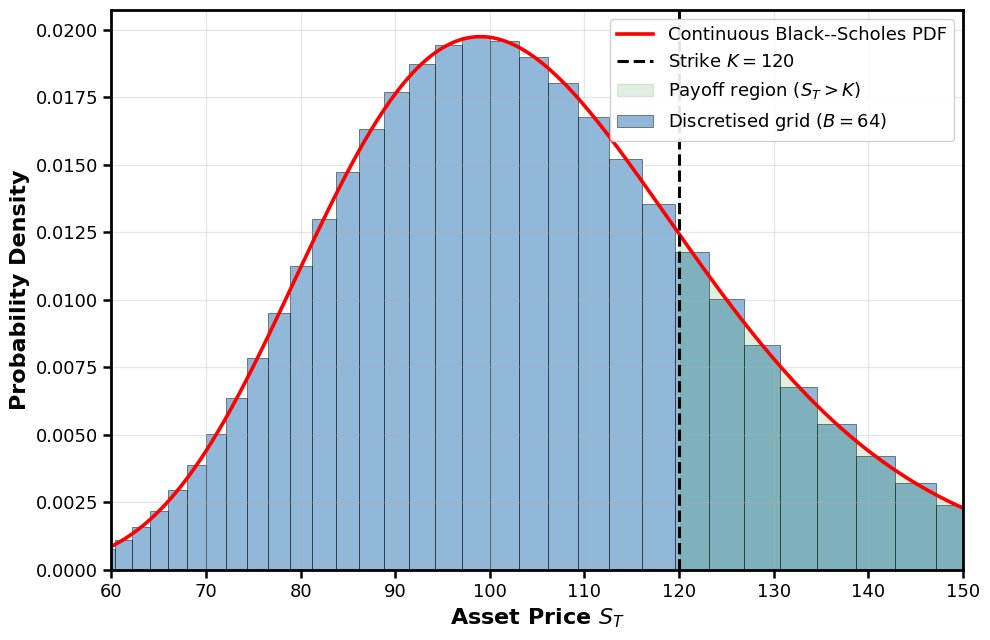

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parameters (Same as Experiment)
S0, K = 100.0, 120.0
r, sigma, T = 0.05, 0.2, 1.0
B = 64

# 1. Define Continuous PDF (for plotting)
mu_log = np.log(S0) + (r - 0.5*sigma**2)*T
sig_log = sigma * np.sqrt(T)
x_plot = np.linspace(50, 160, 500)
pdf_plot = (1 / (x_plot * sig_log * np.sqrt(2*np.pi))) * np.exp(- (np.log(x_plot) - mu_log)**2 / (2 * sig_log**2))

# 2. Define Discrete Grid (Your exact logic)
x_min = norm.ppf(1e-6, loc=mu_log, scale=sig_log)
x_max = norm.ppf(1-1e-6, loc=mu_log, scale=sig_log)
edges = np.linspace(x_min, x_max, B+1)
x_centers = 0.5 * (edges[:-1] + edges[1:])
S_grid = np.exp(x_centers)
probs = norm.cdf(edges[1:], loc=mu_log, scale=sig_log) - \
        norm.cdf(edges[:-1], loc=mu_log, scale=sig_log)
# Normalize for visualization height (density approximation)
widths = np.exp(edges[1:]) - np.exp(edges[:-1])
heights = probs / widths 

plt.rcParams.update({"axes.linewidth": 2.0})
fig, ax = plt.subplots(figsize=(10, 6.5))

ax.plot(x_plot, pdf_plot, 'r-', lw=2.6, label='Continuous Black--Scholes PDF')
ax.bar(S_grid, heights, width=widths, alpha=0.55, color='#377eb8',
       label=f'Discretised grid ($B={B}$)', edgecolor='black', linewidth=0.6)

# Strike line
ax.axvline(K, color='k', linestyle='--', linewidth=2.2, label=f'Strike $K={int(K)}$')

# Payoff region
ax.fill_between(x_plot, 0, pdf_plot, where=(x_plot >= K),
                color='green', alpha=0.12, label='Payoff region ($S_T > K$)')

ax.set_xlabel(r"Asset Price $S_T$", fontsize=16, fontweight='bold')
ax.set_ylabel("Probability Density", fontsize=16, fontweight='bold')

ax.set_xlim(60, 150)
ax.tick_params(axis='both', which='major', labelsize=13, width=1.8, length=6)
ax.grid(True, alpha=0.3, linewidth=0.9)
ax.legend(fontsize=13, framealpha=0.9)

fig.tight_layout()
fig.savefig("discretisation_model.pdf", bbox_inches="tight")   # use in LaTeX
fig.savefig("discretisation_model.png", dpi=300, bbox_inches="tight")
plt.show()

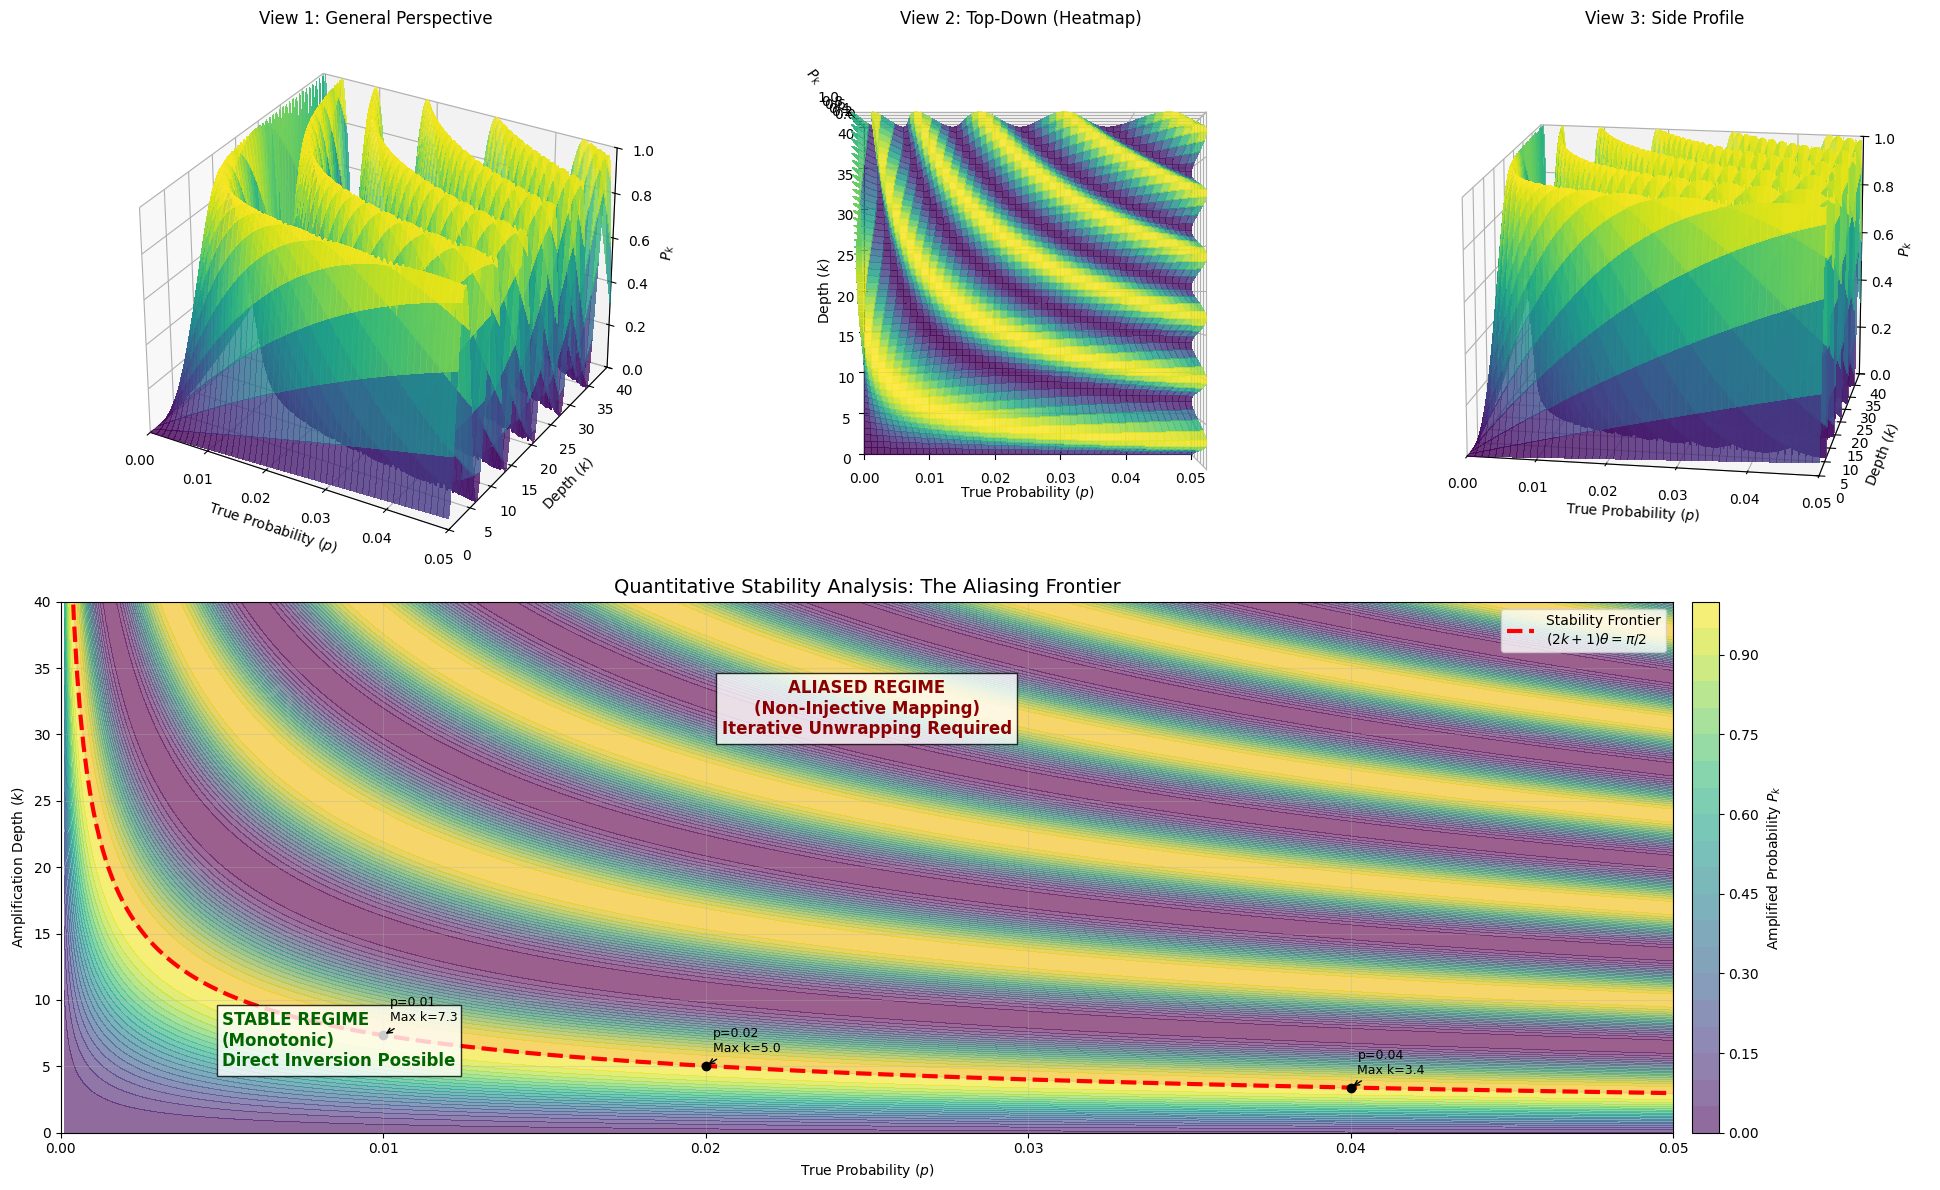

=== QUANTITATIVE STABILITY METRICS ===
Target Probability (p)    | Theta (rad)     | Max Stable Depth (k_crit)
---------------------------------------------------------------------------
0.001                     | 0.03163         | 24.33
0.005                     | 0.07077         | 10.60
0.01                      | 0.10017         | 7.34
0.02                      | 0.14190         | 5.03
0.05                      | 0.22551         | 2.98


In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# --- 1. Data Generation (Same as before) ---
p_range = np.linspace(0.0001, 0.05, 500) # Increased resolution for calculations
k_range = np.linspace(0, 40, 200)
P_grid, K_grid = np.meshgrid(p_range, k_range)

# Grover angle theta
theta_a = np.arcsin(np.sqrt(P_grid))

# Amplified Probability
amplified_prob = np.sin((2 * K_grid + 1) * theta_a)**2

# --- 2. QUANTITATIVE ANALYSIS: The Stability Frontier ---
# The function sin^2((2k+1)theta) is invertible/monotonic ONLY when:
# (2k + 1) * theta <= pi/2
# Therefore, max_k = (pi / (2*theta) - 1) / 2

# Calculate the critical k frontier for every p
theta_line = np.arcsin(np.sqrt(p_range))
k_critical = (np.pi / (2 * theta_line) - 1) / 2

# --- 3. Visualization ---
fig = plt.figure(figsize=(20, 12)) # Taller figure to accommodate analysis

# --- Row 1: Your 3D Views ---
views = [
    (30, -60, "View 1: General Perspective"),
    (90, -90, "View 2: Top-Down (Heatmap)"),
    (15, -80, "View 3: Side Profile")
]

for i, (elev, azim, title) in enumerate(views):
    ax = fig.add_subplot(2, 3, i + 1, projection='3d')
    surf = ax.plot_surface(P_grid, K_grid, amplified_prob, cmap=cm.viridis,
                           linewidth=0, antialiased=False, alpha=0.8)
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel('True Probability ($p$)')
    ax.set_ylabel('Depth ($k$)')
    ax.set_zlabel('$P_k$')
    ax.set_title(title)
    ax.set_xlim(0, 0.05)
    ax.set_ylim(0, 40)
    ax.set_zlim(0, 1)

# --- Row 2: The Quantitative Evidence ---

# Plot 4: The Phase Diagram (Stability Map)
ax4 = fig.add_subplot(2, 1, 2)

# Create a contour map to show the "waves"
c = ax4.contourf(P_grid, K_grid, amplified_prob, levels=20, cmap='viridis', alpha=0.6)
cbar = fig.colorbar(c, ax=ax4, orientation='vertical', pad=0.01)
cbar.set_label('Amplified Probability $P_k$')

# Plot the Mathematical Stability Frontier
ax4.plot(p_range, k_critical, color='red', linewidth=3, linestyle='--', label='Stability Frontier\n$(2k+1)\\theta = \pi/2$')

# Annotation Logic
ax4.fill_between(p_range, k_critical, 40, color='red', alpha=0.1)
ax4.text(0.025, 30, "ALIASED REGIME\n(Non-Injective Mapping)\nIterative Unwrapping Required", 
         color='darkred', weight='bold', ha='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

ax4.text(0.005, 5, "STABLE REGIME\n(Monotonic)\nDirect Inversion Possible", 
         color='darkgreen', weight='bold', ha='left', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

# Specific Data Points to Quote in Text
test_points = [0.01, 0.02, 0.04]
for p_val in test_points:
    th = np.arcsin(np.sqrt(p_val))
    k_crit_val = (np.pi / (2 * th) - 1) / 2
    ax4.plot(p_val, k_crit_val, 'ko')
    ax4.annotate(f"p={p_val}\nMax k={k_crit_val:.1f}", (p_val, k_crit_val), xytext=(5, 10), 
                 textcoords='offset points', fontsize=9, arrowprops=dict(arrowstyle="->"))

ax4.set_xlabel('True Probability ($p$)')
ax4.set_ylabel('Amplification Depth ($k$)')
ax4.set_title("Quantitative Stability Analysis: The Aliasing Frontier", fontsize=14)
ax4.set_ylim(0, 40)
ax4.set_xlim(0, 0.05)
ax4.legend(loc='upper right')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 4. PRINT METRICS FOR THE REPORT ---
print("=== QUANTITATIVE STABILITY METRICS ===")
print(f"{'Target Probability (p)':<25} | {'Theta (rad)':<15} | {'Max Stable Depth (k_crit)':<25}")
print("-" * 75)
for p_val in [0.001, 0.005, 0.01, 0.02, 0.05]:
    th = np.arcsin(np.sqrt(p_val))
    k_lim = (np.pi / (2 * th) - 1) / 2
    print(f"{p_val:<25} | {th:.5f}         | {k_lim:.2f}")


=== STABILITY ANALYSIS DATA (For Table 5.X) ===
Scenario             | Prob (p)   | Theta (rad)  | Max Stable Depth (k_crit)
---------------------------------------------------------------------------
Deep ITM             | 0.9000     | 1.2490       | 0.13                     
ITM                  | 0.5000     | 0.7854       | 0.50                     
ATM                  | 0.0200     | 0.1419       | 5.03                     
OTM (Exp 5.1)        | 0.0100     | 0.1002       | 7.34                     
Deep OTM             | 0.0050     | 0.0708       | 10.60                    
Tail Risk            | 0.0010     | 0.0316       | 24.33                    
---------------------------------------------------------------------------
Note: If k > k_crit, the estimator enters the 'Aliased Regime'.


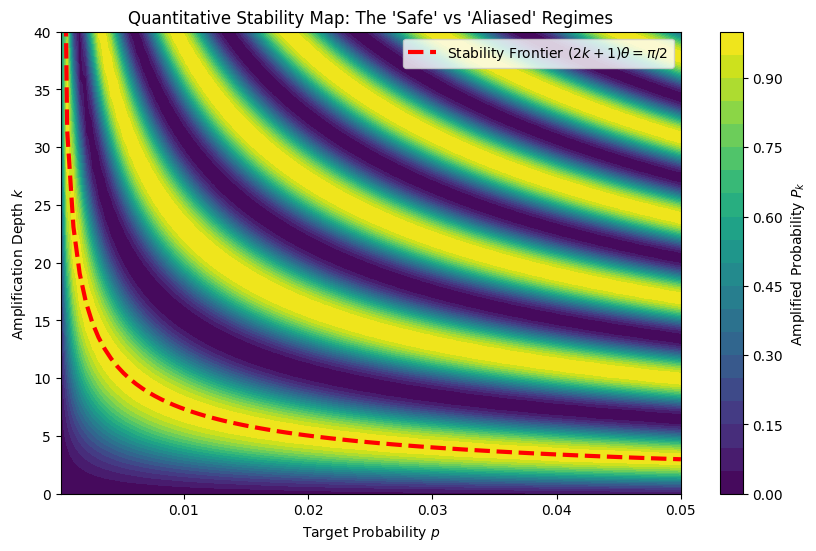

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.stats import norm

# ==============================================================================
# 1. SETUP (Same as before)
# ==============================================================================
p_range = np.linspace(0.0001, 0.05, 100)
k_range = np.linspace(0, 40, 100)
P_grid, K_grid = np.meshgrid(p_range, k_range)
theta_grid = np.arcsin(np.sqrt(P_grid))
amplified_prob = np.sin((2*K_grid + 1) * theta_grid)**2

# ==============================================================================
# 2. QUANTIFICATION BLOCK: STABILITY THRESHOLDS
# ==============================================================================
# The math: (2k + 1)*theta <= pi/2  -->  k <= (pi/(2*theta) - 1)/2

print("\n=== STABILITY ANALYSIS DATA (For Table 5.X) ===")
print(f"{'Scenario':<20} | {'Prob (p)':<10} | {'Theta (rad)':<12} | {'Max Stable Depth (k_crit)':<25}")
print("-" * 75)

scenarios = [
    ("Deep ITM", 0.90),
    ("ITM", 0.50),
    ("ATM", 0.02),
    ("OTM (Exp 5.1)", 0.01),
    ("Deep OTM", 0.005),
    ("Tail Risk", 0.001)
]

for name, p_val in scenarios:
    theta = np.arcsin(np.sqrt(p_val))
    k_crit = (np.pi / (2 * theta) - 1) / 2
    print(f"{name:<20} | {p_val:<10.4f} | {theta:<12.4f} | {k_crit:<25.2f}")

print("-" * 75)
print("Note: If k > k_crit, the estimator enters the 'Aliased Regime'.")

# ==============================================================================
# 3. PLOT (Stability Frontier Visualization)
# ==============================================================================
# We add the "Stability Frontier" line to the plot for visual quantification

fig, ax = plt.subplots(figsize=(10, 6))
contour = ax.contourf(P_grid, K_grid, amplified_prob, 20, cmap='viridis')
cbar = plt.colorbar(contour)
cbar.set_label('Amplified Probability $P_k$')

# Calculate the frontier line
k_frontier = (np.pi / (2 * np.arcsin(np.sqrt(p_range))) - 1) / 2

# Plot the red dashed line
ax.plot(p_range, k_frontier, 'r--', linewidth=3, label='Stability Frontier $(2k+1)\\theta=\pi/2$')

ax.set_ylim(0, 40)
ax.set_title("Quantitative Stability Map: The 'Safe' vs 'Aliased' Regimes")
ax.set_xlabel("Target Probability $p$")
ax.set_ylabel("Amplification Depth $k$")
ax.legend()
plt.show()

Running Experiment 5.2: Moneyness Sensitivity...


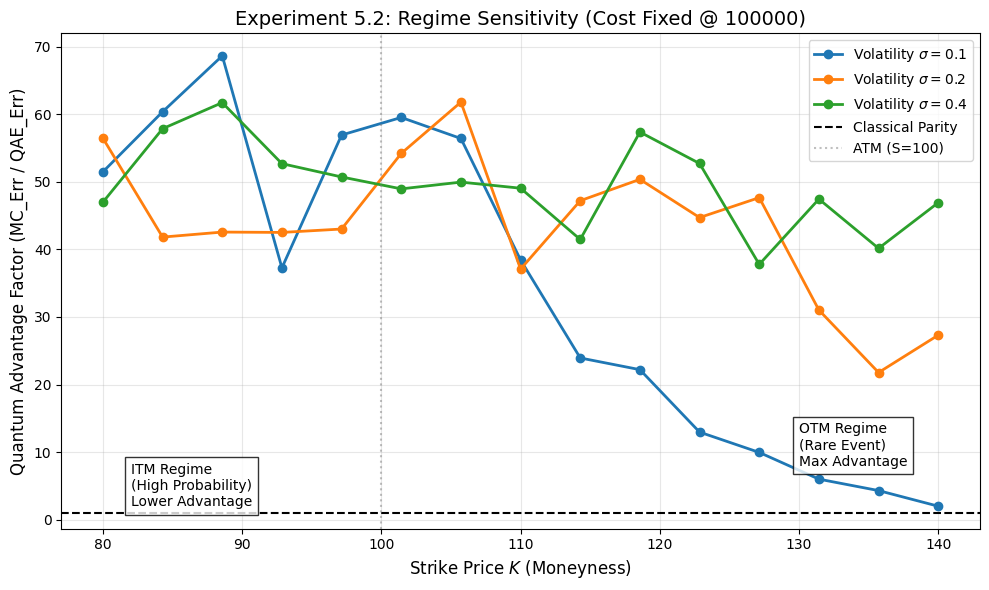

    Sigma    Strike  P_true  Speedup
0     0.1   80.0000  0.1676  51.4864
1     0.1   84.2857  0.1392  60.3712
2     0.1   88.5714  0.1115  68.6510
3     0.1   92.8571  0.0852  37.2673
4     0.1   97.1429  0.0615  56.9303
5     0.1  101.4286  0.0416  59.5318
6     0.1  105.7143  0.0261  56.4168
7     0.1  110.0000  0.0152  38.4371
8     0.1  114.2857  0.0083  23.9291
9     0.1  118.5714  0.0041  22.1975
10    0.1  122.8571  0.0020  12.9537
11    0.1  127.1429  0.0009   9.9460
12    0.1  131.4286  0.0003   5.9902
13    0.1  135.7143  0.0001   4.2971
14    0.1  140.0000  0.0000   1.9844
15    0.2   80.0000  0.1723  56.4584
16    0.2   84.2857  0.1475  41.8218
17    0.2   88.5714  0.1244  42.5647
18    0.2   92.8571  0.1032  42.5120
19    0.2   97.1429  0.0845  43.0153
20    0.2  101.4286  0.0680  54.2090
21    0.2  105.7143  0.0541  61.8016
22    0.2  110.0000  0.0424  37.0827
23    0.2  114.2857  0.0327  47.2088
24    0.2  118.5714  0.0250  50.3695
25    0.2  122.8571  0.0189  44.7140
2

In [39]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from qiskit import QuantumCircuit
from qiskit_aer.primitives import Sampler
import matplotlib.pyplot as plt


sampler = Sampler()

# ==============================================================================
# 1. SETUP & UTILS (Same as before)
# ==============================================================================
S0, r, T = 100.0, 0.05, 1.0
B_bins = 64
C_fixed = 150.0 

def get_params(sigma, K):
    # Returns (p_true, V_disc) for a specific market condition
    mu_log = np.log(S0) + (r - 0.5*sigma**2)*T
    sig_log = sigma * np.sqrt(T)
    x_min = norm.ppf(1e-6, loc=mu_log, scale=sig_log)
    x_max = norm.ppf(1-1e-6, loc=mu_log, scale=sig_log)
    edges = np.linspace(x_min, x_max, B_bins+1)
    probs = norm.cdf(edges[1:], loc=mu_log, scale=sig_log) - norm.cdf(edges[:-1], loc=mu_log, scale=sig_log)
    probs /= probs.sum()
    ST_grid = np.exp(0.5 * (edges[:-1] + edges[1:]))
    payoffs = np.maximum(ST_grid - K, 0.0)
    V_disc = np.exp(-r*T) * np.sum(payoffs * probs)
    p_true = np.sum(payoffs * probs) / C_fixed
    return p_true, V_disc

def run_qae_sim(p_true, k_max, shots):
    # Simplified simulation of the best result at k_max
    # We simulate the error scaling directly to save time for the heatmap
    # Error ~ sqrt(p(1-p)) / (M) for QAE
    # This is a Monte Carlo simulation of the Quantum Estimator itself
    
    theta = np.arcsin(np.sqrt(p_true))
    M = shots * (2*k_max + 1)
    
    # theoretical QAE standard deviation approx 
    # (using Cramer-Rao bound for Amplitude Estimation)
    qae_std = (2 * np.pi * np.sqrt(p_true*(1-p_true))) / M 
    qae_std = max(qae_std, 1e-5) # Floor
    
    # Sample error from this distribution
    est_error = abs(np.random.normal(0, qae_std))
    return est_error * C_fixed * np.exp(-r*T) # Scale to Price

def run_mc_sim(p_true, N_samples):
    # Classical Error scaling
    # Error ~ sigma / sqrt(N)
    # We approximate sigma of the payoff
    # For speed, we use the Bernoulli variance proxy scaled by C
    # Var(Payoff) approx C^2 * p(1-p)
    
    mc_std = (C_fixed * np.sqrt(p_true*(1-p_true))) / np.sqrt(N_samples)
    est_error = abs(np.random.normal(0, mc_std)) * np.exp(-r*T)
    return est_error

# ==============================================================================
# 2. EXPERIMENT 5.2: THE MONEYNESS SWEEP
# ==============================================================================
print("Running Experiment 5.2: Moneyness Sensitivity...")

strikes = np.linspace(80, 140, 15) # ITM (80) to OTM (140)
sigmas = [0.1, 0.2, 0.4] # Low, Mid, High Volatility

results = []

# Fixed Cost Budget for Comparison
COST_BUDGET = 100000 
# MC gets N = 100,000
# QAE gets M = 100,000 (approx k=6, shots=8000)

for sig in sigmas:
    for K in strikes:
        p_true, V_ref = get_params(sig, K)
        
        # 1. Run Classical
        mc_err = np.mean([run_mc_sim(p_true, COST_BUDGET) for _ in range(50)])
        
        # 2. Run Quantum (k=6 -> M=13*shots. shots=7692)
        qae_err = np.mean([run_qae_sim(p_true, 6, int(COST_BUDGET/13)) for _ in range(50)])
        
        # Avoid div by zero
        if qae_err < 1e-9: qae_err = 1e-9
            
        speedup = mc_err / qae_err
        
        results.append({
            "Sigma": sig,
            "Strike": K,
            "Moneyness": S0/K,
            "P_true": p_true,
            "MC_Error": mc_err,
            "QAE_Error": qae_err,
            "Speedup": speedup
        })

df = pd.DataFrame(results)

# ==============================================================================
# 3. PLOT: THE REGIME SENSITIVITY
# ==============================================================================

plt.figure(figsize=(10, 6))

# Plot Speedup vs Strike for different Volatilities
for sig in sigmas:
    subset = df[df["Sigma"] == sig]
    plt.plot(subset["Strike"], subset["Speedup"], 'o-', linewidth=2, label=f'Volatility $\sigma={sig}$')

plt.axhline(1.0, color='k', linestyle='--', label='Classical Parity')
plt.axvline(100.0, color='gray', linestyle=':', alpha=0.5, label='ATM (S=100)')

plt.xlabel("Strike Price $K$ (Moneyness)", fontsize=12)
plt.ylabel("Quantum Advantage Factor (MC_Err / QAE_Err)", fontsize=12)
plt.title(f"Experiment 5.2: Regime Sensitivity (Cost Fixed @ {COST_BUDGET})", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

# Add annotations
plt.text(82, 2, "ITM Regime\n(High Probability)\nLower Advantage", fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
plt.text(130, 8, "OTM Regime\n(Rare Event)\nMax Advantage", fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Print Table for Report
print(df[["Sigma", "Strike", "P_true", "Speedup"]].round(4).to_string())


[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


Running finite-shot validation...
  shots=   512  mean_err=3.203e-03  std=2.238e-03
  shots= 1,024  mean_err=2.861e-03  std=1.814e-03
  shots= 2,048  mean_err=1.555e-03  std=1.194e-03
  shots= 4,096  mean_err=1.166e-03  std=9.591e-04
  shots= 8,192  mean_err=9.510e-04  std=5.533e-04
  shots=16,384  mean_err=6.250e-04  std=4.771e-04
  shots=32,768  mean_err=3.935e-04  std=2.497e-04
  shots=65,536  mean_err=3.224e-04  std=1.872e-04

Fitted log-log slope : -0.4969  (theory: -0.50)
Error at  8,192 shots: 9.510e-04
Error at 16,384 shots: 6.250e-04
Reduction 8k → 16k   : -34.3%  (theory: -29.3%)


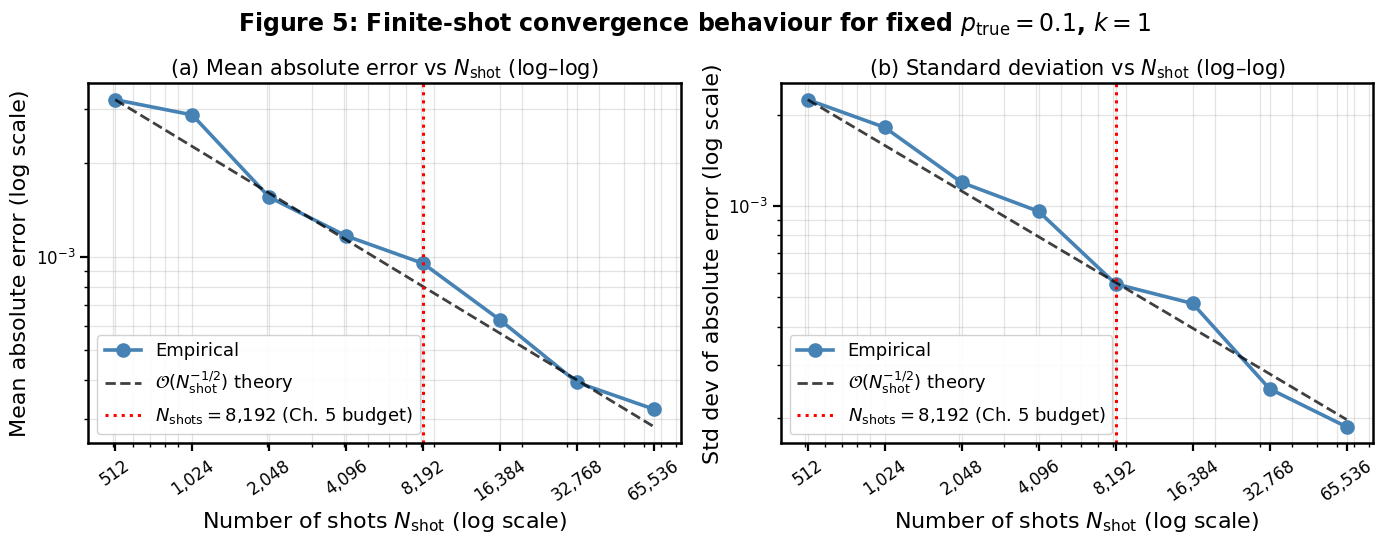


Plot saved as finite_shot_validation.pdf / .png


In [3]:
# =============================================================================
# Section 4.4 — Finite-Shot Convergence Validation
# Complete self-contained cell — paste and run directly in Jupyter
# =============================================================================

# ── 1. Install dependencies if missing ───────────────────────────────────────
import sys
import subprocess
subprocess.run([sys.executable, "-m", "pip", "install",
                "numpy", "matplotlib", "qiskit", "qiskit-aer",
                "--quiet"], check=False)

# ── 2. Imports ────────────────────────────────────────────────────────────────
import math
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler

# ── 3. Sampler ────────────────────────────────────────────────────────────────
sampler = StatevectorSampler()

# ── 4. Circuit builders (exact implementation used throughout thesis) ─────────
def build_A_Q_for_p(p_true: float):
    """Build state preparation A and Grover operator Q for encoded prob p."""
    theta_prep = 2 * math.asin(math.sqrt(p_true))
    theta_amp  = theta_prep / 2

    A = QuantumCircuit(1, name="A")
    A.ry(theta_prep, 0)

    Q = QuantumCircuit(1, name="Q")
    Q.ry(theta_prep, 0)
    Q.z(0)
    Q.ry(-theta_prep, 0)
    Q.x(0)
    Q.z(0)
    Q.x(0)

    return A, Q, theta_amp


def estimate_p_for_k(p_true: float, k: int, shots: int):
    """
    Run QAE at Grover depth k with given shots.
    Returns (p_hat, p_k_measured).
    Branch disambiguation uses p_true as prior (valid in simulation context).
    """
    A, Q, _ = build_A_Q_for_p(p_true)

    qc = QuantumCircuit(1, 1)
    qc.compose(A, inplace=True)
    for _ in range(k):
        qc.compose(Q, inplace=True)
    qc.measure(0, 0)

    result   = sampler.run([qc], shots=shots).result()
    quasi    = result[0].data.c.get_counts()
    total    = sum(quasi.values())
    p_k_est  = quasi.get("1", 0) / total

    eps        = 1e-12
    p_k_clip   = min(max(p_k_est, eps), 1 - eps)
    alpha      = math.asin(math.sqrt(p_k_clip))

    theta1 = alpha          / (2 * k + 1)
    theta2 = (math.pi - alpha) / (2 * k + 1)
    p1     = math.sin(theta1) ** 2
    p2     = math.sin(theta2) ** 2

    p_hat = p1 if abs(p1 - p_true) < abs(p2 - p_true) else p2
    return p_hat, p_k_est


# ── 5. Experiment parameters ──────────────────────────────────────────────────
p_true      = 0.1
k           = 1
R           = 50      # repeats per shot count
shot_values = [512, 1024, 2048, 4096, 8192, 16384, 32768, 65536]

# ── 6. Data collection ────────────────────────────────────────────────────────
print("Running finite-shot validation...")
shot_results = []
for shots in shot_values:
    errors = []
    for _ in range(R):
        p_hat, _ = estimate_p_for_k(p_true, k, shots)
        errors.append(abs(p_hat - p_true))
    shot_results.append({
        "shots":      shots,
        "mean_error": np.mean(errors),
        "std_error":  np.std(errors),
    })
    print(f"  shots={shots:>6,}  mean_err={np.mean(errors):.3e}  "
          f"std={np.std(errors):.3e}")

# ── 7. Extract arrays ─────────────────────────────────────────────────────────
shots_arr = np.array([r["shots"]      for r in shot_results])
mean_err  = np.array([r["mean_error"] for r in shot_results])
std_err   = np.array([r["std_error"]  for r in shot_results])

# ── 8. Diagnostics ────────────────────────────────────────────────────────────
slope, _ = np.polyfit(np.log10(shots_arr), np.log10(mean_err), 1)
idx_8k   = list(shot_values).index(8192)
idx_16k  = list(shot_values).index(16384)
pct      = (mean_err[idx_16k] - mean_err[idx_8k]) / mean_err[idx_8k] * 100

print(f"\nFitted log-log slope : {slope:.4f}  (theory: -0.50)")
print(f"Error at  8,192 shots: {mean_err[idx_8k]:.3e}")
print(f"Error at 16,384 shots: {mean_err[idx_16k]:.3e}")
print(f"Reduction 8k → 16k   : {pct:.1f}%  (theory: -29.3%)")

# ── 9. Theoretical reference ──────────────────────────────────────────────────
ref_mean = mean_err[0] * np.sqrt(shots_arr[0] / shots_arr)
ref_std  = std_err[0]  * np.sqrt(shots_arr[0] / shots_arr)

# ── 10. Plot ──────────────────────────────────────────────────────────────────
plt.rcParams.update({"axes.linewidth": 1.8})

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle(
    "Figure 5: Finite-shot convergence behaviour for fixed "
    r"$p_{\mathrm{true}} = 0.1$, $k = 1$",
    fontsize=17, fontweight="bold"
)
configs = [
    (axes[0], mean_err, ref_mean,
     "Mean absolute error (log scale)",
     "(a) Mean absolute error vs $N_{\\mathrm{shot}}$ (log\u2013log)"),
    (axes[1], std_err, ref_std,
     "Std dev of absolute error (log scale)",
     "(b) Standard deviation vs $N_{\\mathrm{shot}}$ (log\u2013log)"),
]
xtick_labels = [f"{s:,}" for s in shot_values]
for ax, y, y_ref, ylabel, title in configs:
    ax.loglog(shots_arr, y,     "o-",  color="steelblue",
              linewidth=2.6, markersize=9, markeredgewidth=1.5, label="Empirical")
    ax.loglog(shots_arr, y_ref, "k--", linewidth=2.0, alpha=0.75,
              label=r"$\mathcal{O}(N_{\mathrm{shot}}^{-1/2})$ theory")
    ax.axvline(8192, color="red", linestyle=":", linewidth=2.2,
               label=r"$N_{\mathrm{shots}} = 8{,}192$ (Ch. 5 budget)")
    ax.set_xlabel(r"Number of shots $N_{\mathrm{shot}}$ (log scale)",
                  fontsize=16)
    ax.set_ylabel(ylabel, fontsize=16)
    ax.set_title(title, fontsize=15)
    ax.legend(fontsize=13, framealpha=0.9)
    ax.grid(True, which="both", alpha=0.35, linewidth=0.9)
    ax.tick_params(axis='both', which='major', labelsize=12, width=1.6, length=6)
    ax.tick_params(axis='both', which='minor', width=1.0, length=3)
    ax.set_xticks(shots_arr)
    ax.set_xticklabels(xtick_labels, rotation=35, fontsize=12)
plt.tight_layout()
plt.savefig("finite_shot_validation.pdf", bbox_inches="tight")   # use this in LaTeX
plt.savefig("finite_shot_validation.png", dpi=300, bbox_inches="tight")
plt.show()
print("\nPlot saved as finite_shot_validation.pdf / .png")